In [ ]:
include("ALST_BEK.jl")
include("LST_BEK.jl")
using NonlinearEigenproblems
using LinearAlgebra
using ProgressMeter

In [ ]:
ω=0
N=199
Ro=1
Co=2
baseflow="Vonkarmen.txt"
θ = range(0,length=N+1,stop=pi)
x = reshape(-cos.(θ), N+1, 1)
c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
X = repeat(x, 1, N+1);
dX = X - X';
D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
D = D - diagm(vec(sum(D, dims=2))); 
for i=1:N+1
    D[i,:]=D[i,:].*((2*x[i]^3-x[i]^2+3*x[i]-4)^2/(20*(6*x[i]^2-2*x[i]+3)))
end
for i=1:N+1
    x[i]=(4*x[i]^3-2*x[i]^2+6*x[i]+12)/(-2*x[i]^3+x[i]^2-3*x[i]+4)
    if x[i]>50
        x[i]=50
    end
end
D2=D^2

In [ ]:
# 计算部分
Cr_all=nothing
R_all=nothing
@showprogress 1 "Conputing..."     for R=300:1:340
    ω=0
    x_0=R
    β=32/R
    A0,A1,A2,A3,A4,dU,dV,dW=KEB_SpatialMode.KEB_LST_ALL(baseflow,N,ω,β,R,Ro,Co,1)
    nep = PEP([A0,A1,A2,A3,A4]); #Create a PEP object
    sc=10
    nep1 = shift_and_scale(nep,scale=sc);
    mult_scale = norm(nep1.A[end]);
    nep2 = PEP(nep1.A ./ mult_scale);
    λ1,v2 = iar(nep2,σ=0.05,neigs=5,maxit=500);
    λ_2 = sc*λ1
    min_imag_abs = Inf
    min_index = 0 
    for i in 1:5
        eigval = λ_2[i]
        if -0.1<imag(eigval) < 0
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end  
    if min_index==0
        for i in 1:5
            eigval = λ_2[i]
            if -0.2<imag(eigval)<0.2
                curr_imag_abs = abs(imag(eigval))
                if curr_imag_abs < min_imag_abs
                    min_imag_abs = curr_imag_abs
                    min_index = i
                end
            end
        end
    end
    α_ori=λ_2[min_index,1]
    phi=v2[:,min_index]
    A0_A,A1_A,A2_A,A3_A,A4_A=KEB_ADJ.KEB_ALST(baseflow,N,ω,β,R,Ro,Co)
    A0_A = A0_A';A1_A = A1_A';A2_A = transpose(A2);A3_A = transpose(A3);A4_A = transpose(A4)
    nep = PEP([A0_A,A1_A,A2_A,A3_A,A4_A]);
    sc=10
    nep1 = shift_and_scale(nep,scale=sc);
    mult_scale = norm(nep1.A[end]);
    nep2 = PEP(nep1.A ./ mult_scale);
    λ1,v1 = iar(nep2,σ=0.05,neigs=5,maxit=500);
    λ_1 = sc*λ1
    min_imag_abs = Inf
    min_index = 0
    for i in 1:5
        eigval = λ_1[i]
        if -0.1<imag(eigval)<0
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end
    if min_index==0
        for i in 1:5
            eigval = λ_1[i]
            if -0.1<imag(eigval)<0.1
                curr_imag_abs = abs(imag(eigval))
                if curr_imag_abs < min_imag_abs
                    min_imag_abs = curr_imag_abs
                    min_index = i
                end
            end
        end
    end
    α_adj=λ_1[min_index,1]
    psi=v1[:,min_index]
    index2=findmax(abs,psi[1:N+1])
    psi=psi./psi[index2[2]]
    index1=findmax(abs,phi[1:N+1])
    phi=phi./phi[index1[2]]
    A0,A1,A2,A3,A4,dU,dV,dW=KEB_SpatialMode.KEB_LST_ALL(baseflow,N,ω,β,R,Ro,Co,1)
    L=A1 + (α_ori + α_adj) * A2 + (α_ori^2 + α_ori * α_adj + α_adj^2) * A3 + (α_ori^2 + α_adj^2)*(α_ori + α_adj) * A4
    Q=transpose(psi)*(L*phi)


    
    η_wall=(dU[1]*β-dV[1]*α_ori)*exp(-α_ori*(im*x_0+2*α_ori))
    insert!(psi,1,0)
    insert!(psi,2,0)
    insert!(psi,N,0)
    insert!(psi,N+1,0)
    insert!(psi,N+2,0)
    insert!(psi,2N+2,0)
    insert!(phi,1,0)
    insert!(phi,2,0)
    insert!(phi,N,0)
    insert!(phi,N+1,0)
    insert!(phi,N+2,0)
    insert!(phi,2N+2,0)
    A_0,A_1,A_2,A_3,A_4=KEB_ADJ.KEB_Parameter_Matrix(baseflow,N,ω,α_ori,β,R,Ro,Co,0)
    d2psi=2*(psi[3]-psi[2]+(((x[3]-x[2])/(x[2]-x[1])))*(psi[1]-psi[2]))/((x[3]+x[2]-2*x[1])*(x[3]-x[2]))
    dphi=2*dU[1]*exp(-0.5*α_ori*(2*im*x_0+4*α_ori))
    dpsi_wall=((psi[N+3]-psi[N+2])/(x[2]-x[1]))
    dpsi0=[0 dpsi_wall]
    phi0=[0;η_wall]
    d2psi0=[d2psi 0]
    dphi0=[dphi;0]
    BC_0=dpsi0*A_2*phi0-d2psi0*A_4*dphi0
    Cr=-im*(BC_0/Q)
    Cr=abs.(Cr)
    Cr_all=[Cr_all;Cr]
    R_all=[R_all;R]
end
R_all=R_all[2:end]
Cr_all=Cr_all[2:end]
data=[R_all Cr_all]

In [75]:
R = 400
data = [0 0 0 0]
for R = 300 : 2 : 500
# R = 400
ω = 7.9/R
    x_0=R
    β=40/R
    A0_A,A1_A,A2_A,A3_A,A4_A=KEB_ADJ.KEB_ALST(baseflow,N,ω,β,R,Ro,Co)
    # A0_A = A0_A';A1_A = A1_A';A2_A = transpose(A2);A3_A = transpose(A3);A4_A = transpose(A4)
    nep = PEP([A0_A,A1_A,A2_A,A3_A,A4_A]);
    sc=10
    nep1 = shift_and_scale(nep,scale=sc);
    mult_scale = norm(nep1.A[end]);
    nep2 = PEP(nep1.A ./ mult_scale);
    λ1,v1 = iar(nep2,σ=0.08,neigs=1,maxit=500,tol = 1e-12);
    λ_1 = sc*λ1
    phi=v1[:,1]
    insert!(phi,1,0)
    insert!(phi,2,0)
    insert!(phi,N,0)
    insert!(phi,N+1,0)
    insert!(phi,N+2,0)
    insert!(phi,2N+2,0)
    α_ori = λ_1[1]
    h = phi[1:N+1]
    eta = phi[N+2:2N+2]
    dh = D* h
    deta = D* eta
    dphi=[D*phi[1:N+1];D*phi[N+2:2N+2]]
    f_ori=(im*dh-(β/α_ori)*eta)/(α_ori+β^2 /α_ori+im/R)
    g_ori=(eta+β*f_ori)/α_ori
    h_ori=phi[1:N+1]
    norm_para = findmax(abs.(f_ori))[1]
    f_ori ./= norm_para
    g_ori ./= norm_para
    h_ori ./= norm_para
    data = [data ;[R λ_1 (1/R)abs.(D*f_ori)[1] (1/R)abs.(D*g_ori)[1]]]
    writedlm("log.dat",data[2:end,:])
end

In [ ]:
f_ori

In [ ]:

plot(x,abs.(f_ori),xlims=[0,8])
plot!(x,abs.(g_ori))
plot!(x,abs.(h_ori))

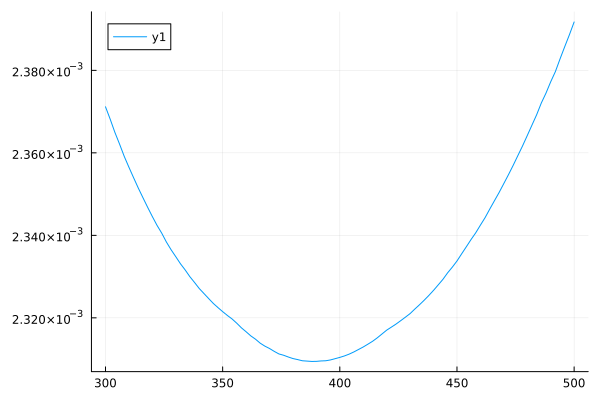

In [76]:
using Plots
plot(real(data[2:end,1]),real(data[2:end,3]))

In [ ]:
psi=v1
phi=v1
α_ori = λ1[1]
dpsi=[D*psi[1:N+1];D*psi[N+2:2N+2]]
dphi=[D*phi[1:N+1];D*phi[N+2:2N+2]]
f_ori=(im*(dphi)[1:N+1]-(β/α_ori)*phi[N+2:2N+2])/(α_ori+β^2 /α_ori+im/R)
g_ori=(phi[N+2:2N+2]+β*f_ori)/α_ori
h_ori=phi[1:N+1]

In [ ]:
a=nothing
b=nothing
for R=300:5:400
    ω=0
    x_0=R
    β=32/R
    A0,A1,A2,A3,A4,dU,dV,dW=KEB_SpatialMode.KEB_LST_ALL(baseflow,N,ω,β,R,Ro,Co,1)
    nep = PEP([A0,A1,A2,A3,A4]); #Create a PEP object
    sc=10
    nep1 = shift_and_scale(nep,scale=sc);
    mult_scale = norm(nep1.A[end]);
    nep2 = PEP(nep1.A ./ mult_scale);
    λ1,v2 = iar(nep2,σ=0.05,neigs=5,maxit=500);
    λ_2 = sc*λ1
    min_imag_abs = Inf
    min_index = 0 
    for i in 1:5
        eigval = λ_2[i]
        if -0.1<imag(eigval) < 0
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end  
    if min_index==0
        for i in 1:5
            eigval = λ_2[i]
            if -0.2<imag(eigval)<0.2
                curr_imag_abs = abs(imag(eigval))
                if curr_imag_abs < min_imag_abs
                    min_imag_abs = curr_imag_abs
                    min_index = i
                end
            end
        end
    end
    α_ori=λ_2[min_index,1]
    phi=v2[:,min_index]
    η_wall=(dU[1]*β-dV[1]*α_ori)*exp(-0.5*α_ori*(2*im*x_0+4*α_ori))
    b=[b;η_wall]

end
b=b[2:end]
using Plots
plot(abs.(b))

In [ ]:
using Plots
plot(x,abs.(psi[1:N+1]))
plot!(x,abs.(phi[1:N+1]))

In [ ]:
@show α_ori 

In [ ]:
transpose(psi)*(A1 + (α_ori + α_adj) * A2 + (α_ori^2 + α_ori * α_adj + α_adj^2) * A3 + (α_ori^2 + α_adj^2)*(α_ori + α_adj)*A4)*phi

In [ ]:
@show α_1 α

In [ ]:
L_m=(A0+A1*α_1+A2*α_1^2+A3*α_1^3+A4*α_1^4)
transpose(v1)*L_m*v2

In [ ]:
L_adjoint_n=(A0_A+A1_A*α_1+A2_A*α_1^2+A3_A*α_1^3+A4_A*α_1^4)
transpose(L_adjoint_n*v1)*v2

In [ ]:
L_adjoint_n

In [ ]:
L_n = (A0 + A1*α_1 + A2*α_1^2 + A3*α_1^3 + A4*α_1^4)
transpose(v1)*(L_n*v2)

In [ ]:
transpose(v1)*((L_m-L_n)*v2)

In [ ]:
using Plots
plot(R_all,Cr_all)

In [ ]:
R=323
ω=0
x_0=R
β=32/R
A0_A,A1_A,A2_A,A3_A,A4_A=KEB_ADJ.KEB_ALST(baseflow,N,ω,β,R,Ro,Co)
nep = PEP([A0_A,A1_A,A2_A,A3_A,A4_A]); #Create a PEP object
sc=10
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
λ1,v1 = iar(nep2,σ=0.05,neigs=20,maxit=500);
λ_1 = sc*λ1
min_imag_abs = Inf
min_index = 0
for i in 1:20
    eigval = λ_1[i]
    if -0.1<imag(eigval)<0
        curr_imag_abs = abs(imag(eigval))
        if curr_imag_abs < min_imag_abs
            min_imag_abs = curr_imag_abs
            min_index = i
        end
    end
end
if min_index==0
    for i in 1:20
        eigval = λ_1[i]
        if -0.1<imag(eigval)<0.1
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end
end
α_adj=λ_1[min_index,1]
v1=v1[:,min_index]
A0,A1,A2,A3,A4,dU,dV=KEB_SpatialMode.KEB_LST_ALL(baseflow,N,ω,β,R,Ro,Co,1)
nep = PEP([A0,A1,A2,A3,A4]); #Create a PEP object
sc=10
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
λ1,v2 = iar(nep2,σ=0.05,neigs=20,maxit=500);
λ_2 = sc*λ1
min_imag_abs = Inf
min_index = 0 
for i in 1:20
    eigval = λ_2[i]
    if -0.1<imag(eigval) < 0
        curr_imag_abs = abs(imag(eigval))
        if curr_imag_abs < min_imag_abs
            min_imag_abs = curr_imag_abs
            min_index = i
        end
    end
end  
if min_index==0
    for i in 1:20
        eigval = λ_2[i]
        if -0.2<imag(eigval)<0.2
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end
end
α_ori=λ_2[min_index,1]
v2=v2[:,min_index]
insert!(v1,1,0)
insert!(v1,2,0)
insert!(v1,N,0)
insert!(v1,N+1,0)
insert!(v1,N+2,0)
insert!(v1,2N+2,0)
insert!(v2,1,0)
insert!(v2,2,0)
insert!(v2,N,0)
insert!(v2,N+1,0)
insert!(v2,N+2,0)
insert!(v2,2N+2,0)
psi=v1
phi=v2
dpsi=[D*psi[1:N+1];D*psi[N+2:2N+2]]
dphi=[D*phi[1:N+1];D*phi[N+2:2N+2]]
f_ori=(im*(dphi)[1:N+1]-(β/α_ori)*phi[N+2:2N+2])/(α_ori+β^2 /α_ori+im/R)
g_ori=(phi[N+2:2N+2]+β*f_ori)/α_ori
h_ori=phi[1:N+1]
f_adj=(im*(dpsi)[1:N+1]-(β/α_adj)*psi[N+2:2N+2])/(α_adj+β^2 /α_adj+im/R)
g_adj=(psi[N+2:2N+2]+β*f_adj)/α_adj
h_adj=psi[1:N+1]
df_adj=D*f_adj
dg_adj=D*g_adj

In [ ]:
@show dg_adj[1] df_adj[1]

In [ ]:
using Plots
plot(x,abs.(h2),xlims=[0,8])
plot!(x,abs.(f2))
plot!(x,abs.(g2))

In [ ]:
using DelimitedFiles
writedlm("n=40.dat",data ,'\t')